# US-China Tension Index - Exploratory Data Analysis

This notebook explores the US-China Tension (UCT) Index dataset.

**Dataset:** `us-china-tension.csv`

**Description:** Monthly US-China Tension Index from 1993 to 2024.

**Citation:** Rogers, Sun, and Sun (2024), U.S.-China Tension, Working paper

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)

DATA_PATH = Path('../../../data/raw/us-china-tension.csv')

## 1. Load and Clean Data

In [3]:
# Load dataset
df = pd.read_csv(DATA_PATH)

print("First 5 rows (raw):")
display(df.head())

# Keep only the first two columns (date and UCT)
df = df.iloc[:, :2]
df.columns = ['date', 'UCT']

# Remove rows with missing UCT values
df = df.dropna(subset=['UCT'])

# Parse date (format: YYYYmM)
df['date'] = pd.to_datetime(df['date'], format='%Ym%m')

# Extract year and month
df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month

# Sort by date
df = df.sort_values('date').reset_index(drop=True)

print("\nCleaned dataset:")
display(df.head())
print("\nData types:")
print(df.dtypes)

First 5 rows (raw):


,date,UCT,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,"Please cite as Rogers, Sun, and Sun (2024), U.S.-China Tension, Working paper"
0,1993m1,44.030612,NaN,NaN,NaN,NaN,NaN
1,1993m2,42.167156,NaN,NaN,NaN,NaN,NaN
2,1993m3,38.646377,NaN,NaN,NaN,NaN,NaN
3,1993m4,37.983290,NaN,NaN,NaN,NaN,NaN
4,1993m5,50.461390,NaN,NaN,NaN,NaN,NaN



Cleaned dataset:


,date,UCT,year,month
0,1993-01-01,44.030612,1993,1
1,1993-02-01,42.167156,1993,2
2,1993-03-01,38.646377,1993,3
3,1993-04-01,37.983290,1993,4
4,1993-05-01,50.461390,1993,5



Data types:
date     datetime64[ns]
UCT             float64
year              int32
month             int32
dtype: object


## 2. Data Overview

In [4]:
print("Dataset Shape:", df.shape)
print("\nDate range:", df['date'].min(), "to", df['date'].max())
print("Total months:", len(df))
print("\nDataset Info:")
df.info()

Dataset Shape: (374, 4)

Date range: 1993-01-01 00:00:00 to 2024-02-01 00:00:00
Total months: 374

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 374 entries, 0 to 373
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   date    374 non-null    datetime64[ns]
 1   UCT     374 non-null    float64       
 2   year    374 non-null    int32         
 3   month   374 non-null    int32         
dtypes: datetime64[ns](1), float64(1), int32(2)
memory usage: 8.9 KB


## 3. Descriptive Statistics

In [5]:
print("Descriptive Statistics for UCT Index:")
display(df['UCT'].describe())

print("\nAdditional Statistics:")
print(f"Skewness: {df['UCT'].skew():.4f}")
print(f"Kurtosis: {df['UCT'].kurtosis():.4f}")

Descriptive Statistics for UCT Index:


count    374.000000
mean     100.000000
std       42.547360
min       37.983290
25%       67.986686
50%       90.908382
75%      120.808852
max      349.945501
Name: UCT, dtype: float64


Additional Statistics:
Skewness: 1.5516
Kurtosis: 4.4404


## 4. Time Series Visualization

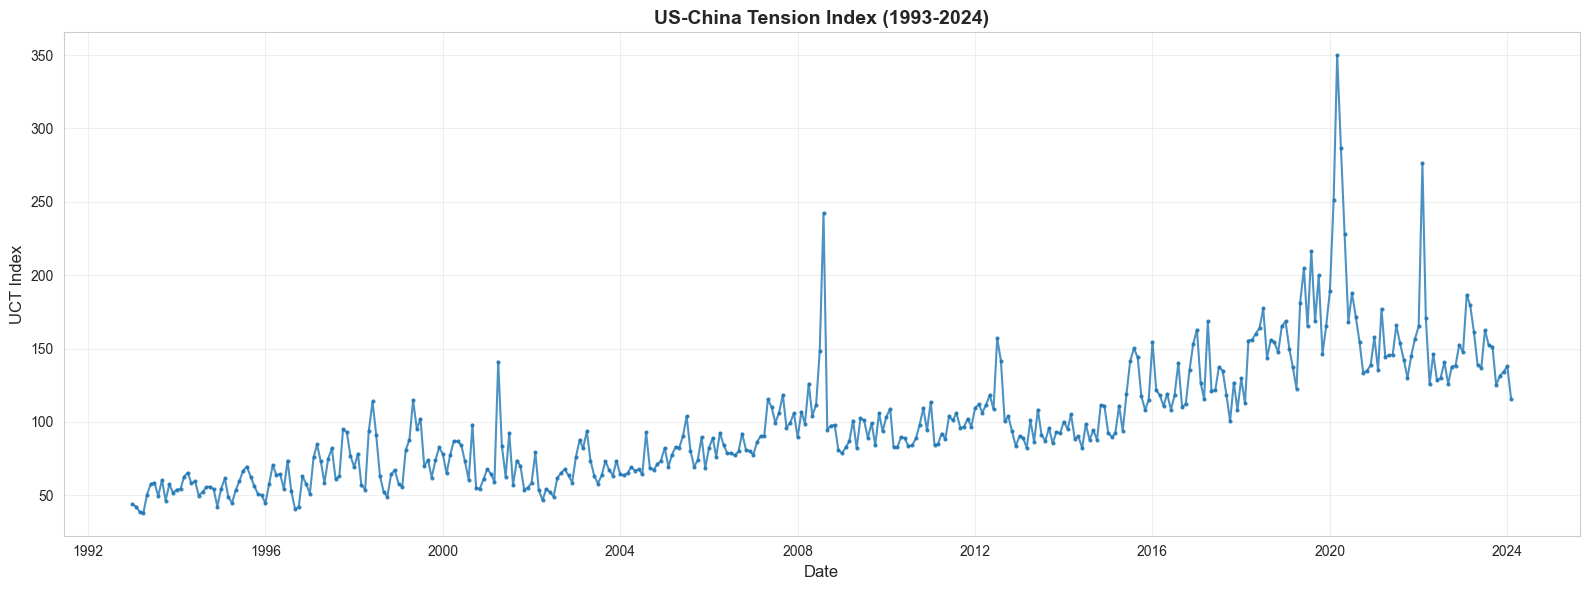

In [6]:
fig, ax = plt.subplots(figsize=(16, 6))
ax.plot(df['date'], df['UCT'], linewidth=1.5, marker='o', markersize=2, alpha=0.8)
ax.set_title('US-China Tension Index (1993-2024)', fontsize=14, fontweight='bold')
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('UCT Index', fontsize=12)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

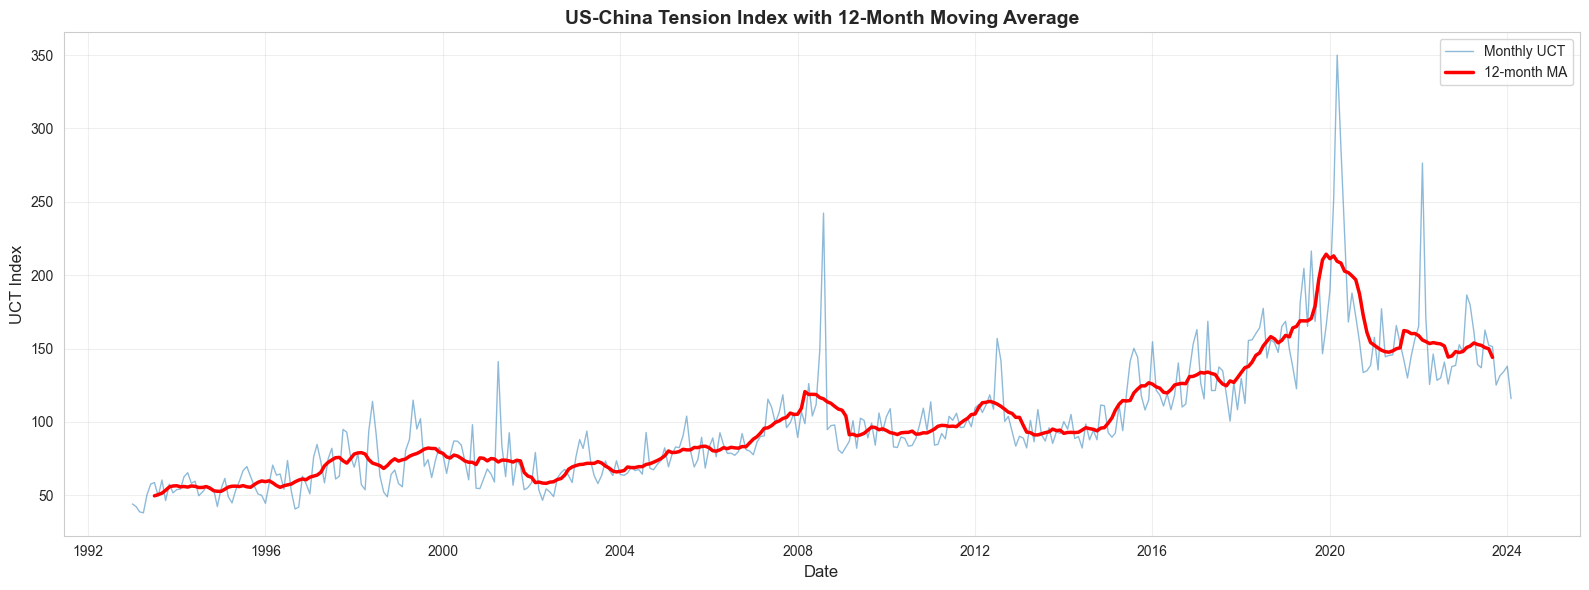

In [7]:
# With moving average
df['MA_12m'] = df['UCT'].rolling(window=12, center=True).mean()

fig, ax = plt.subplots(figsize=(16, 6))
ax.plot(df['date'], df['UCT'], linewidth=1, alpha=0.5, label='Monthly UCT')
ax.plot(df['date'], df['MA_12m'], linewidth=2.5, label='12-month MA', color='red')
ax.set_title('US-China Tension Index with 12-Month Moving Average', fontsize=14, fontweight='bold')
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('UCT Index', fontsize=12)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 5. Distribution Analysis

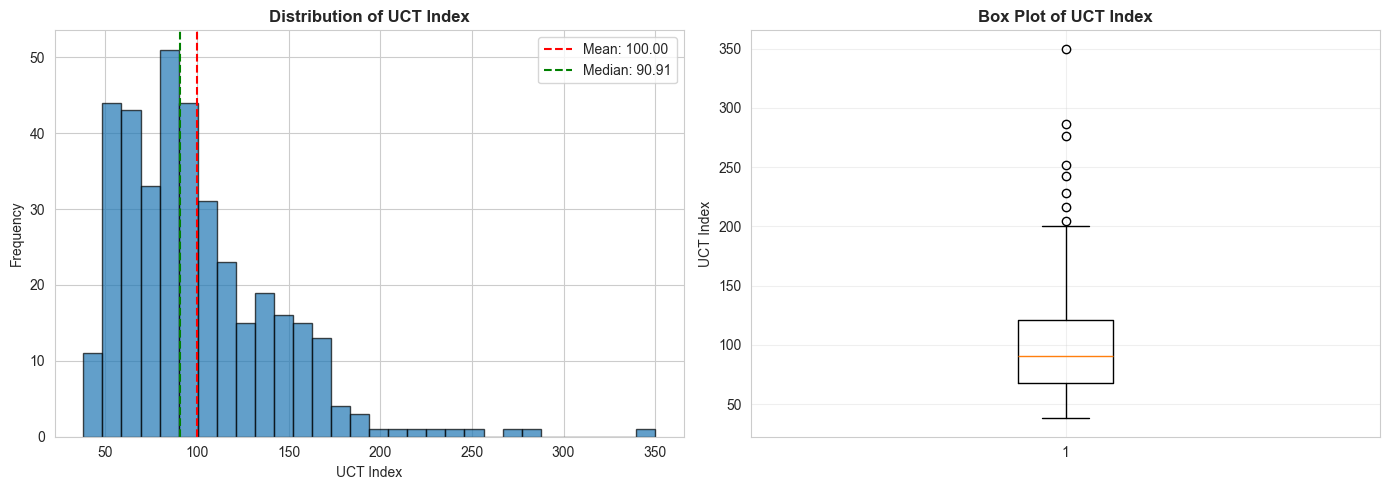

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['UCT'], bins=30, edgecolor='black', alpha=0.7)
axes[0].axvline(df['UCT'].mean(), color='red', linestyle='--', label=f'Mean: {df["UCT"].mean():.2f}')
axes[0].axvline(df['UCT'].median(), color='green', linestyle='--', label=f'Median: {df["UCT"].median():.2f}')
axes[0].set_title('Distribution of UCT Index', fontsize=12, fontweight='bold')
axes[0].set_xlabel('UCT Index')
axes[0].set_ylabel('Frequency')
axes[0].legend()

axes[1].boxplot(df['UCT'], vert=True)
axes[1].set_title('Box Plot of UCT Index', fontsize=12, fontweight='bold')
axes[1].set_ylabel('UCT Index')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 6. Temporal Patterns

Yearly Statistics:


,mean,std,min,max,count
year,,,,,
1993,49.570351,7.870455,37.983290,60.393822,12
1994,55.251931,5.993344,42.280036,65.359799,12
1995,56.546820,7.587977,44.750807,69.539258,12
1996,57.062162,10.774990,40.578912,73.633752,12
1997,74.059669,13.635626,50.972579,94.856223,12
1998,71.073817,19.726660,48.914594,113.926123,12
1999,79.719922,18.030738,55.751706,114.788334,12
2000,73.330731,14.228073,54.501838,98.075066,12
2001,73.388260,24.293235,53.706189,141.070289,12


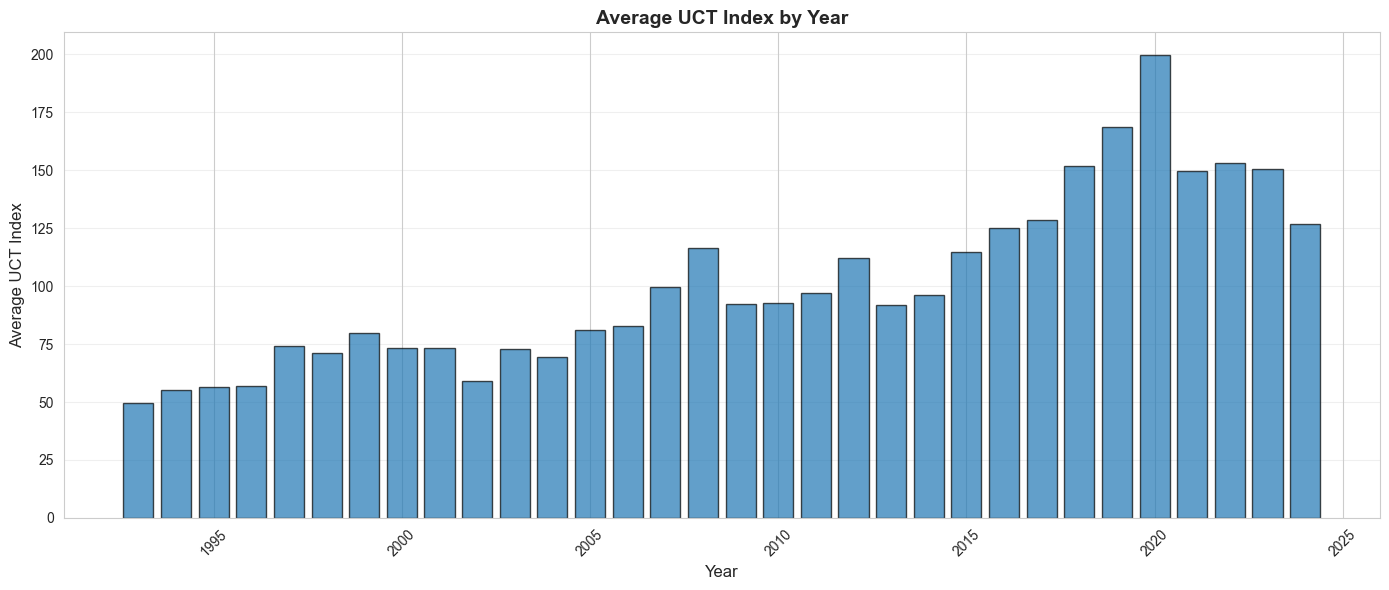

In [9]:
# Yearly statistics
yearly_stats = df.groupby('year')['UCT'].agg(['mean', 'std', 'min', 'max', 'count'])
print("Yearly Statistics:")
display(yearly_stats)

fig, ax = plt.subplots(figsize=(14, 6))
ax.bar(yearly_stats.index, yearly_stats['mean'], alpha=0.7, edgecolor='black')
ax.set_title('Average UCT Index by Year', fontsize=14, fontweight='bold')
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Average UCT Index', fontsize=12)
ax.grid(True, alpha=0.3, axis='y')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 7. Key Events Analysis

In [10]:
# Identify peaks (highest tension periods)
top_10_tension = df.nlargest(10, 'UCT')[['date', 'UCT']]
print("Top 10 Highest Tension Periods:")
display(top_10_tension)

# Identify lowest tension periods
bottom_10_tension = df.nsmallest(10, 'UCT')[['date', 'UCT']]
print("\nTop 10 Lowest Tension Periods:")
display(bottom_10_tension)

Top 10 Highest Tension Periods:


,date,UCT
326,2020-03-01,349.945501
327,2020-04-01,286.569397
349,2022-02-01,276.434349
325,2020-02-01,251.488385
187,2008-08-01,242.301214
328,2020-05-01,228.161812
319,2019-08-01,216.456960
317,2019-06-01,204.624444
321,2019-10-01,199.948600
324,2020-01-01,189.214733



Top 10 Lowest Tension Periods:


,date,UCT
3,1993-04-01,37.983290
2,1993-03-01,38.646377
44,1996-09-01,40.578912
45,1996-10-01,41.910493
1,1993-02-01,42.167156
23,1994-12-01,42.280036
0,1993-01-01,44.030612
36,1996-01-01,44.492031
27,1995-04-01,44.750807
9,1993-10-01,46.380456


## 8. Change Analysis

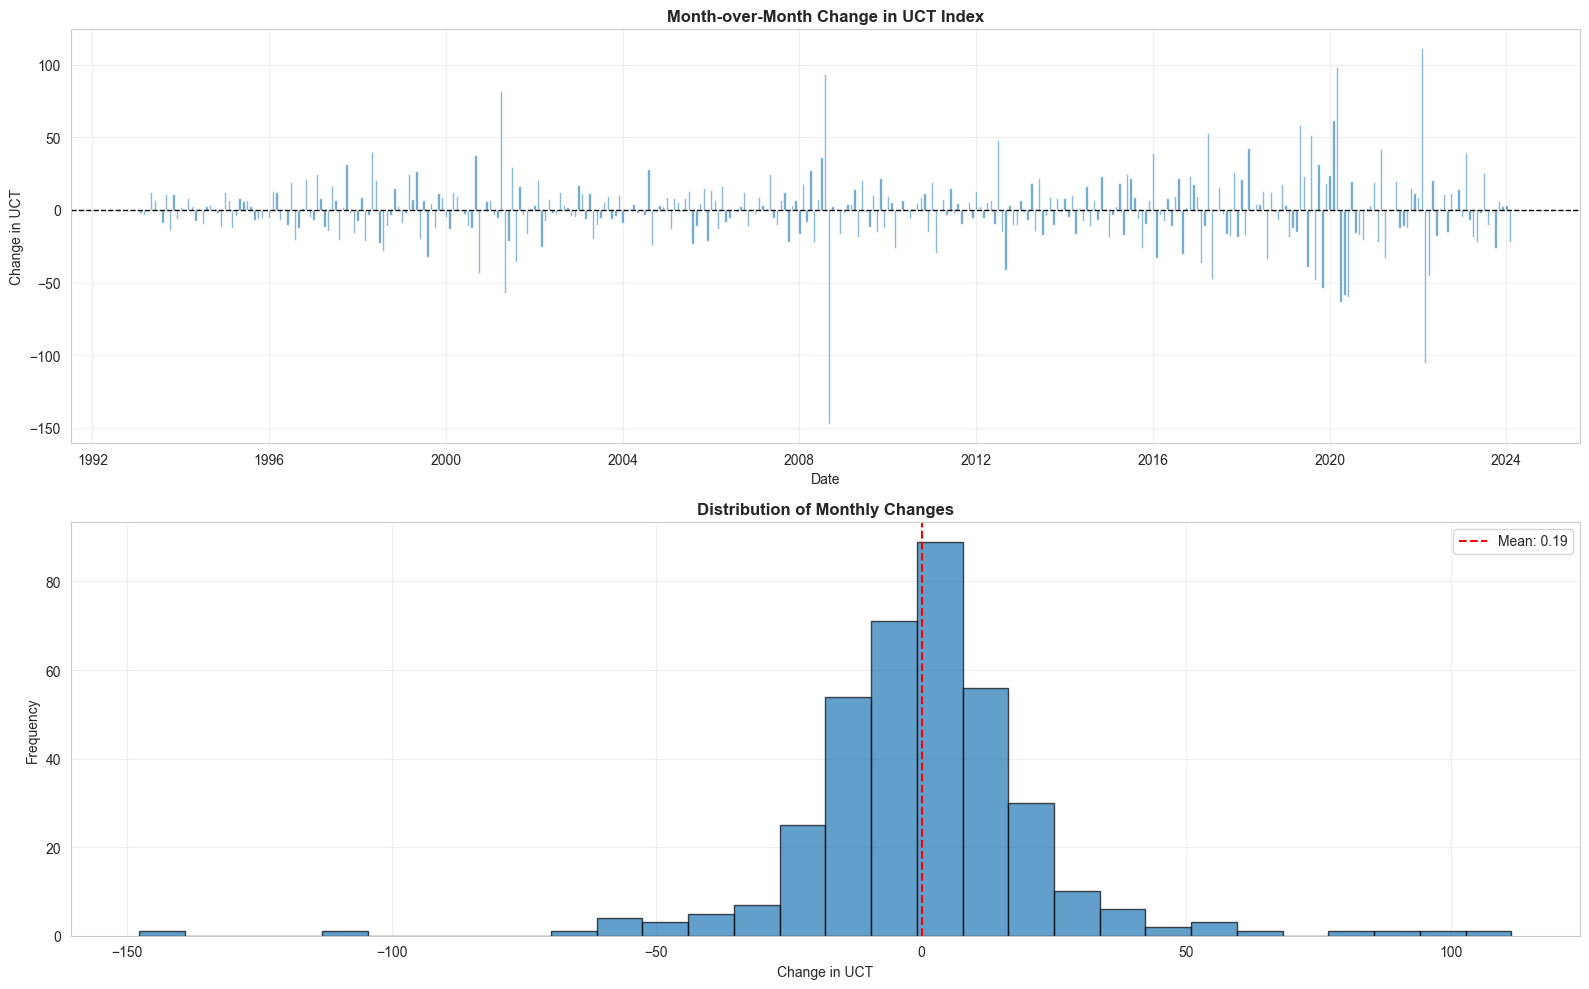

In [11]:
# Calculate month-over-month change
df['UCT_change'] = df['UCT'].diff()
df['UCT_pct_change'] = df['UCT'].pct_change() * 100

fig, axes = plt.subplots(2, 1, figsize=(16, 10))

axes[0].bar(df['date'], df['UCT_change'], alpha=0.7, width=20)
axes[0].axhline(y=0, color='black', linestyle='--', linewidth=1)
axes[0].set_title('Month-over-Month Change in UCT Index', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Date')
axes[0].set_ylabel('Change in UCT')
axes[0].grid(True, alpha=0.3)

axes[1].hist(df['UCT_change'].dropna(), bins=30, edgecolor='black', alpha=0.7)
axes[1].axvline(df['UCT_change'].mean(), color='red', linestyle='--', label=f'Mean: {df["UCT_change"].mean():.2f}')
axes[1].set_title('Distribution of Monthly Changes', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Change in UCT')
axes[1].set_ylabel('Frequency')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 9. Summary

In [12]:
print("=" * 60)
print("KEY FINDINGS - US-CHINA TENSION INDEX")
print("=" * 60)
print(f"\n1. Dataset Coverage:")
print(f"   - Start: {df['date'].min().strftime('%Y-%m')}")
print(f"   - End: {df['date'].max().strftime('%Y-%m')}")
print(f"   - Total Months: {len(df)}")
print(f"\n2. UCT Index Statistics:")
print(f"   - Mean: {df['UCT'].mean():.2f}")
print(f"   - Median: {df['UCT'].median():.2f}")
print(f"   - Std Dev: {df['UCT'].std():.2f}")
print(f"   - Min: {df['UCT'].min():.2f} ({df.loc[df['UCT'].idxmin(), 'date'].strftime('%Y-%m')})")
print(f"   - Max: {df['UCT'].max():.2f} ({df.loc[df['UCT'].idxmax(), 'date'].strftime('%Y-%m')})")
print(f"\n3. Temporal Insights:")
print(f"   - Year with highest avg: {yearly_stats['mean'].idxmax()} ({yearly_stats['mean'].max():.2f})")
print(f"   - Year with lowest avg: {yearly_stats['mean'].idxmin()} ({yearly_stats['mean'].min():.2f})")
print(f"\n4. Volatility:")
print(f"   - Avg Monthly Change: {df['UCT_change'].mean():.2f}")
print(f"   - Std of Changes: {df['UCT_change'].std():.2f}")
print("\n" + "=" * 60)

KEY FINDINGS - US-CHINA TENSION INDEX

1. Dataset Coverage:
   - Start: 1993-01
   - End: 2024-02
   - Total Months: 374

2. UCT Index Statistics:
   - Mean: 100.00
   - Median: 90.91
   - Std Dev: 42.55
   - Min: 37.98 (1993-04)
   - Max: 349.95 (2020-03)

3. Temporal Insights:
   - Year with highest avg: 2020 (199.54)
   - Year with lowest avg: 1993 (49.57)

4. Volatility:
   - Avg Monthly Change: 0.19
   - Std of Changes: 22.49

